In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections.abc import Mapping
from IPython.display import display
from plotting_utils import create_df_runs
import numpy as np
import bambi as bmb
import arviz as az
import itertools
from typing import Tuple, Optional
import xarray as xr


In [2]:
def flatten_run_row_children(row) -> list[dict]:
    """
    Extracts data at the child-level.
    A case with 3 children will return 3 dictionaries.
    """
    run_name = row.run_name
    timestamp_str = run_name.split("__")[0]

    model_string = str(row.model)
    if model_string.lower() == "unknown":
        return []

    results = row.results
    if not isinstance(results, Mapping):
        return []

    output = []

    for case_id, case_data in results.items():
        if case_id == "run_config":
            continue

        duration = case_data.get("duration_seconds")
        if duration is None:
            continue

        # Grab the child_evaluations dictionary (defaulting to an empty dict if missing)
        child_results = case_data.get("child_evaluations", {})

        # Handle if the evaluator stores children as a list of dictionaries
        if isinstance(child_results, list):
            for child in child_results:
                output.append(
                    {
                        "run_name": run_name,
                        "timestamp": pd.to_datetime(timestamp_str),
                        "config_label": row.config_label,
                        "case_id": case_id,
                        "child_id": child.get("child_id", child.get("name", "unknown")),
                        "child_is_correct": int(child.get("is_correct", False)),
                        "duration": float(duration),
                    }
                )

        # Handle if the evaluator stores children as a dictionary {child_id: {data}}
        elif isinstance(child_results, dict):
            for child_id, child_data in child_results.items():
                output.append(
                    {
                        "run_name": run_name,
                        "timestamp": pd.to_datetime(timestamp_str),
                        "config_label": row.config_label,
                        "case_id": case_id,
                        "child_id": child_id,  # e.g., "Alex", "Blake"
                        "child_is_correct": int(child_data.get("is_correct", False)),
                        "duration": float(duration),
                    }
                )

    return output


def flatten_runs_to_children(df_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Creates a DataFrame where every row is an individual child's evaluation.
    """
    flat_data = [
        record
        for row in df_runs.itertuples(index=False)
        for record in flatten_run_row_children(row)
    ]

    return pd.DataFrame(flat_data)

In [4]:
df_runs = create_df_runs()

df_runs created and its head looks like this:


,index,run_name,model,prompt,url_allowed,commit,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,1,2026-03-10T17:32:39.329093__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,55b2687,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.2_no...,Free text rules,claude-sonnet-4-5,"(claude-sonnet-4-5, Accuracy-ChildBenefit-stru...",v2.2,claude-sonnet-4-5 | Free text rules
1,2,2026-03-17T13:27:50.099730__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,True,d62efd3,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.md,Rules via URLs,claude-opus-4-5,"(claude-opus-4-5, Accuracy-ChildBenefit-struct...",v2,claude-opus-4-5 | Rules via URLs
2,3,2026-03-13T09:05:44.994101__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/StructuredSpecifica...,True,c099d04,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,StructuredSpecification-ChildBenefit-v1.md,Structured spec,claude-opus-4-5,"(claude-opus-4-5, StructuredSpecification-Chil...",v1,claude-opus-4-5 | Structured spec
3,4,2026-03-17T19:02:56.554521__Model=claude-opus-...,bedrock/converse/eu.anthropic.claude-opus-4-5-...,agents/TechnicalHypotheses/Accuracy-ChildBenef...,False,78b6027,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,Accuracy-ChildBenefit-structuredOutput-v2.1_no...,Training data only,claude-opus-4-5,"(claude-opus-4-5, Accuracy-ChildBenefit-struct...",v2.1,claude-opus-4-5 | Training data only
4,5,2026-03-12T20:35:57.579893__Model=claude-sonne...,bedrock/converse/eu.anthropic.claude-sonnet-4-...,agents/TechnicalHypotheses/StructuredSpecifica...,True,1877943,{'MULTI_MIXED_THREE_MIXED': {'case_id': 'MULTI...,StructuredSpecification-ChildBenefit-v1.md,Structured spec,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v1,claude-sonnet-4-5 | Structured spec


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",6
"(claude-sonnet-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",5
"(claude-opus-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",5
"(claude-opus-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-sonnet-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.md, True)",5
"(claude-haiku-4-5, StructuredSpecification-ChildBenefit-v1.md, True)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.1_no_links.md, False)",5
"(claude-haiku-4-5, Accuracy-ChildBenefit-structuredOutput-v2.2_no_links_rules_in_prompt.md, False)",5


In [6]:
def prep_data_for_reg(df: pd.DataFrame) -> pd.DataFrame:

    """
    Split the config_label into independent columns
    Using a regex split to safely handle the pipe character and surrounding spaces

    Ensure the outcome is an integer (Bambi expects 0/1 for bernoulli)
    """
    df[['model_name', 'prompt_type']] = df['config_label'].str.split(r'\s+\|\s+', expand=True)

    df['child_is_correct'] = df['child_is_correct'].astype(int)

    return df

In [11]:

def fit_bayesian_logistic_mixed_model(
    df: pd.DataFrame,
    formula: str = "child_is_correct ~ 0 + prompt_type + model_name + (1|case_id)",
    *,
    draws: int = 2000,
    tune: int = 1000,
    chains: int = 4,
    target_accept: float = 0.9,
    family: str = "bernoulli",
    random_seed: Optional[int] = None,
    progressbar: bool = True,
) -> Tuple[bmb.Model, az.InferenceData]:
    """
    Fit a Bayesian logistic mixed-effects model using Bambi.

    This function fits a Bernoulli (logistic) model with optional random effects,
    returning both the compiled Bambi model and the sampled posterior.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataset. Must contain all variables referenced in `formula`.

    formula : str, default="child_is_correct ~ 0 + prompt_type + model_name + (1|case_id)"
        Model formula in Bambi syntax.
        Example interpretation:
        - '0 + prompt_type' estimates a separate coefficient for each prompt type
          (no global intercept).
        - 'model_name' controls for differences between base models.
        - '(1|case_id)' adds a random intercept to account for clustering by case.

    draws : int, default=2000
        Number of posterior samples per chain.

    tune : int, default=1000
        Number of tuning (warm-up) iterations per chain.

    chains : int, default=4
        Number of MCMC chains.

    target_accept : float, default=0.9
        Target acceptance probability for the NUTS sampler (must be between 0 and 1).
        Higher values can improve sampling stability for hierarchical models.

    family : str, default="bernoulli"
        Likelihood family. For binary outcomes, use "bernoulli".

    random_seed : Optional[int], default=None
        Random seed for reproducibility.

    progressbar : bool, default=True
        Whether to display sampling progress.

    Returns
    -------
    model : bmb.Model
        The compiled Bambi model object.

    idata : az.InferenceData
        Posterior samples and diagnostics in ArviZ format.

    Notes
    -----
    - This model is typically used to estimate differences between prompt types
      while controlling for model-level effects and clustering by case.
    - Posterior comparisons (e.g. differences between prompt types) can be computed
      directly from `idata` rather than relying on post-hoc frequentist tests.
    """

    print("Building the Bayesian model...")
    model = bmb.Model(formula, df, family=family)

    print("Sampling the posterior (this may take a few minutes)...")
    idata = model.fit(
        draws=draws,
        tune=tune,
        chains=chains,
        target_accept=target_accept,
        random_seed=random_seed,
        progressbar=progressbar,
    )

    return model, idata

In [19]:

def summarise_model_results(
    idata: az.InferenceData,
    df: pd.DataFrame,
    *,
    prompt_var: str = "prompt_type",
    model_var: str = "model_name",
    round_to: int = 3,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Summarise a fitted Bayesian model and compute pairwise comparisons between prompt types.

    Parameters
    ----------
    idata : az.InferenceData
        Posterior samples returned by Bambi/PyMC.

    df : pd.DataFrame
        Original dataset used for modelling. Used to extract unique prompt labels.

    prompt_var : str, default="prompt_type"
        Name of the prompt coefficient in the model.

    model_var : str, default="model_name"
        Name of the model coefficient in the model.

    round_to : int, default=3
        Number of decimal places for rounding summary outputs.

    Returns
    -------
    summary_df : pd.DataFrame
        ArviZ summary table for selected coefficients.

    pairwise_df : pd.DataFrame
        Pairwise comparison table with:
        - prompt_a
        - prompt_b
        - prob_a_beats_b
        - winner
        - loser
        - prob_winner

    Notes
    -----
    - Pairwise comparisons are computed in log-odds space.
    - `prob_a_beats_b` is the posterior probability that prompt A has a higher coefficient than prompt B.
    - `prob_winner` is always >= 0.5 and reflects the more intuitive direction.
    """

    # ==========================================
    # Model summary
    # ==========================================
    print("\n--- Model Summary ---")
    summary_df = az.summary(idata, var_names=[prompt_var, model_var]).round(round_to)
    print(summary_df)

    # ==========================================
    # Pairwise comparisons
    # ==========================================
    print("\n--- Pairwise Prompt Comparisons ---")

    posterior: xr.DataArray = idata.posterior[prompt_var]

    prompts = df[prompt_var].unique()

    results = []

    for p1, p2 in itertools.combinations(prompts, 2):
        samples_p1 = posterior.sel({f"{prompt_var}_dim": p1}).values
        samples_p2 = posterior.sel({f"{prompt_var}_dim": p2}).values

        prob_p1_better = np.mean(samples_p1 > samples_p2)

        if prob_p1_better > 0.5:
            winner, loser, prob = p1, p2, prob_p1_better
        else:
            winner, loser, prob = p2, p1, 1 - prob_p1_better

        print(f"Probability '{winner}' outperforms '{loser}': {prob * 100:.1f}%")

        results.append(
            {
                "prompt_a": p1,
                "prompt_b": p2,
                "prob_a_beats_b": prob_p1_better,
                "winner": winner,
                "loser": loser,
                "prob_winner": prob,
            }
        )

    pairwise_df = pd.DataFrame(results)

    return summary_df, pairwise_df, posterior

In [5]:
df = flatten_runs_to_children(df_runs)

In [8]:
df = prep_data_for_reg(df)

In [12]:
bayesian_model, idata = fit_bayesian_logistic_mixed_model(df)

Modeling the probability that child_is_correct==1


Building the Bayesian model...
Sampling the posterior (this may take a few minutes)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [prompt_type, model_name, 1|case_id_sigma, 1|case_id_offset]


/Users/sam.rickman/Projects/gds-eligibility-agentic-backend/analysis/.venv/lib/python3.14/site-packages/rich/live.p
y:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 14 seconds.


In [20]:
summary_df, pairwise_df, posterior = summarise_model_results(idata, df)


--- Model Summary ---
                                  mean     sd  hdi_3%  hdi_97%  mcse_mean  \
prompt_type[Free text rules]     3.407  0.250   2.953    3.880      0.009   
prompt_type[Rules via URLs]      2.762  0.243   2.323    3.221      0.009   
prompt_type[Structured spec]     2.957  0.245   2.524    3.435      0.009   
prompt_type[Training data only]  2.517  0.245   2.069    2.979      0.009   
model_name[claude-opus-4-5]      0.656  0.114   0.447    0.876      0.001   
model_name[claude-sonnet-4-5]    0.543  0.121   0.306    0.757      0.001   

                                 mcse_sd  ess_bulk  ess_tail  r_hat  
prompt_type[Free text rules]       0.004     758.0    1874.0    1.0  
prompt_type[Rules via URLs]        0.004     715.0    1567.0    1.0  
prompt_type[Structured spec]       0.004     759.0    2033.0    1.0  
prompt_type[Training data only]    0.004     724.0    2015.0    1.0  
model_name[claude-opus-4-5]        0.001    6112.0    6248.0    1.0  
model_name[claude

In [17]:
summary_df

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
prompt_type[Free text rules],3.407,0.250,2.953,3.880,0.009,0.004,758.0,1874.0,1.0
prompt_type[Rules via URLs],2.762,0.243,2.323,3.221,0.009,0.004,715.0,1567.0,1.0
prompt_type[Structured spec],2.957,0.245,2.524,3.435,0.009,0.004,759.0,2033.0,1.0
prompt_type[Training data only],2.517,0.245,2.069,2.979,0.009,0.004,724.0,2015.0,1.0
model_name[claude-opus-4-5],0.656,0.114,0.447,0.876,0.001,0.001,6112.0,6248.0,1.0
model_name[claude-sonnet-4-5],0.543,0.121,0.306,0.757,0.001,0.001,6757.0,6024.0,1.0


In [18]:
pairwise_df

,prompt_a,prompt_b,prob_a_beats_b,winner,loser,prob_winner
0,Free text rules,Rules via URLs,1.000000,Free text rules,Rules via URLs,1.000000
1,Free text rules,Structured spec,0.999625,Free text rules,Structured spec,0.999625
2,Free text rules,Training data only,1.000000,Free text rules,Training data only,1.000000
3,Rules via URLs,Structured spec,0.057750,Structured spec,Rules via URLs,0.942250
4,Rules via URLs,Training data only,0.962875,Rules via URLs,Training data only,0.962875
5,Structured spec,Training data only,0.999750,Structured spec,Training data only,0.999750


In [22]:
def compute_odds_ratios(
    df: pd.DataFrame,
    posterior: xr.DataArray,
    *,
    prompt_var: str = "prompt_type",
    dim_name: str = "prompt_type_dim",
    round_to: int = 2,
    print_results: bool = True,
) -> pd.DataFrame:
    """
    Compute pairwise effect sizes (odds ratios) between prompt types.

    Parameters
    ----------
    df : pd.DataFrame
        Original dataset. Used to extract unique prompt labels.

    posterior : xr.DataArray
        Posterior samples for the prompt coefficients (log-odds scale).
        Typically: idata.posterior["prompt_type"].

    prompt_var : str, default="prompt_type"
        Column name in `df` representing prompt types.

    dim_name : str, default="prompt_type_dim"
        Dimension name in the posterior corresponding to prompt levels.

    round_to : int, default=2
        Number of decimal places for reporting.

    print_results : bool, default=True
        Whether to print results to console.

    Returns
    -------
    results_df : pd.DataFrame
        Pairwise odds ratios with:
        - prompt_a
        - prompt_b
        - median_odds_ratio
        - lower_95
        - upper_95

    Notes
    -----
    - Odds ratios are computed by exponentiating differences in log-odds.
    - An odds ratio > 1 means prompt A performs better than prompt B.
    - Credible intervals are computed from the posterior distribution.
    """

    if print_results:
        print("\n--- Effect Sizes (Odds Ratios) ---")

    prompts = df[prompt_var].unique()

    results = []

    for p1, p2 in itertools.combinations(prompts, 2):
        samples_p1 = posterior.sel({dim_name: p1}).values
        samples_p2 = posterior.sel({dim_name: p2}).values

        odds_ratio_samples = np.exp(samples_p1 - samples_p2)

        median_or = np.median(odds_ratio_samples)
        lower = np.percentile(odds_ratio_samples, 2.5)
        upper = np.percentile(odds_ratio_samples, 97.5)

        if print_results:
            print(
                f"'{p1}' vs '{p2}': "
                f"Median OR = {median_or:.{round_to}f} "
                f"[{lower:.{round_to}f}, {upper:.{round_to}f}]"
            )

        results.append(
            {
                "prompt_a": p1,
                "prompt_b": p2,
                "median_odds_ratio": median_or,
                "lower_95": lower,
                "upper_95": upper,
            }
        )

    results_df = pd.DataFrame(results)

    return results_df

In [25]:
odds_ratios_df = compute_odds_ratios(df, posterior)


--- Effect Sizes (Odds Ratios) ---
'Free text rules' vs 'Rules via URLs': Median OR = 1.90 [1.47, 2.50]
'Free text rules' vs 'Structured spec': Median OR = 1.57 [1.20, 2.06]
'Free text rules' vs 'Training data only': Median OR = 2.44 [1.83, 3.22]
'Rules via URLs' vs 'Structured spec': Median OR = 0.82 [0.64, 1.05]
'Rules via URLs' vs 'Training data only': Median OR = 1.28 [0.98, 1.66]
'Structured spec' vs 'Training data only': Median OR = 1.55 [1.18, 2.04]


In [21]:
print("\n--- Effect Sizes (Odds Ratios) ---")
prompts = df['prompt_type'].unique()
for p1, p2 in itertools.combinations(prompts, 2):
    samples_p1 = posterior.sel(prompt_type_dim=p1).values
    samples_p2 = posterior.sel(prompt_type_dim=p2).values
    
    # Subtracting in log-odds space and exponentiating gives the Odds Ratio
    odds_ratio_samples = np.exp(samples_p1 - samples_p2)
    median_or = np.median(odds_ratio_samples)
    
    print(f"'{p1}' vs '{p2}': Median Odds Ratio = {median_or:.2f}")
    # E.g., An OR of 2.0 means P1 is twice as likely to yield a correct answer as P2


--- Effect Sizes (Odds Ratios) ---
'Free text rules' vs 'Rules via URLs': Median Odds Ratio = 1.90
'Free text rules' vs 'Structured spec': Median Odds Ratio = 1.57
'Free text rules' vs 'Training data only': Median Odds Ratio = 2.44
'Rules via URLs' vs 'Structured spec': Median Odds Ratio = 0.82
'Rules via URLs' vs 'Training data only': Median Odds Ratio = 1.28
'Structured spec' vs 'Training data only': Median Odds Ratio = 1.55


In [ ]:
# ==========================================
# 1. DATA PREPARATION
# ==========================================
# Assuming your data is already loaded into a variable called 'df'

# Split the config_label into independent columns
# Using a regex split to safely handle the pipe character and surrounding spaces
df[['model_name', 'prompt_type']] = df['config_label'].str.split(r'\s+\|\s+', expand=True)

# Ensure the outcome is an integer (Bambi expects 0/1 for bernoulli)
df['child_is_correct'] = df['child_is_correct'].astype(int)

# ==========================================
# 2. MODEL DEFINITION & FITTING
# ==========================================
# The formula:
# '0 + prompt_type'   -> Gives us an independent estimate for every prompt
# 'model_name'        -> Controls for the LLM base capability
# '(1|case_id)'       -> Accounts for the nested clustering (random intercept per case)
formula = "child_is_correct ~ 0 + prompt_type + model_name + (1|case_id)"

print("Building the Bayesian model...")
bayesian_model = bmb.Model(formula, df, family="bernoulli")

print("Sampling the posterior (this may take a few minutes)...")
# We use target_accept=0.9 to help the sampler navigate the random effects smoothly
idata = bayesian_model.fit(draws=2000, tune=1000, chains=4, target_accept=0.9)

# ==========================================
# 3. ANALYSIS & PAIRWISE COMPARISONS
# ==========================================
print("\n--- Model Summary ---")
# This gives you the high-level summary of the coefficients
print(az.summary(idata, var_names=["prompt_type", "model_name"]))

print("\n--- Pairwise Prompt Comparisons ---")
# Extract the posterior distributions for the prompt types
# These are in log-odds space
prompt_posteriors = idata.posterior["prompt_type"]

# Get the unique prompt types from your dataframe
prompts = df['prompt_type'].unique()

# Loop through every possible pair of prompts
for p1, p2 in itertools.combinations(prompts, 2):
    # Extract the thousands of simulated samples for each prompt
    samples_p1 = prompt_posteriors.sel(prompt_type_dim=p1).values
    samples_p2 = prompt_posteriors.sel(prompt_type_dim=p2).values
    
    # Calculate the probability that P1 is better than P2
    # We do this by seeing how often the P1 samples are greater than the P2 samples
    prob_p1_better = np.mean(samples_p1 > samples_p2)
    
    # If the probability is less than 50%, it's more intuitive to flip the statement
    if prob_p1_better > 0.5:
        winner, loser, prob = p1, p2, prob_p1_better
    else:
        winner, loser, prob = p2, p1, (1 - prob_p1_better)
        
    print(f"Probability '{winner}' outperforms '{loser}': {prob * 100:.1f}%")

# ==========================================
# 4. OPTIONAL: EFFECT SIZE (ODDS RATIOS)
# ==========================================
# If you want to know *how much* better one is than another in a readable metric:
print("\n--- Effect Sizes (Odds Ratios) ---")
for p1, p2 in itertools.combinations(prompts, 2):
    samples_p1 = prompt_posteriors.sel(prompt_type_dim=p1).values
    samples_p2 = prompt_posteriors.sel(prompt_type_dim=p2).values
    
    # Subtracting in log-odds space and exponentiating gives the Odds Ratio
    odds_ratio_samples = np.exp(samples_p1 - samples_p2)
    median_or = np.median(odds_ratio_samples)
    
    print(f"'{p1}' vs '{p2}': Median Odds Ratio = {median_or:.2f}")
    # E.g., An OR of 2.0 means P1 is twice as likely to yield a correct answer as P2

Modeling the probability that child_is_correct==1


Building the Bayesian model...
Sampling the posterior (this may take a few minutes)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [prompt_type, model_name, 1|case_id_sigma, 1|case_id_offset]


/Users/sam.rickman/Projects/gds-eligibility-agentic-backend/analysis/.venv/lib/python3.14/site-packages/rich/live.p
y:260: UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.



--- Model Summary ---
                                  mean     sd  hdi_3%  hdi_97%  mcse_mean  \
prompt_type[Free text rules]     3.394  0.259   2.899    3.868      0.010   
prompt_type[Rules via URLs]      2.748  0.254   2.290    3.240      0.010   
prompt_type[Structured spec]     2.939  0.253   2.481    3.428      0.010   
prompt_type[Training data only]  2.504  0.255   2.049    3.010      0.010   
model_name[claude-opus-4-5]      0.656  0.115   0.455    0.886      0.001   
model_name[claude-sonnet-4-5]    0.543  0.119   0.325    0.769      0.001   

                                 mcse_sd  ess_bulk  ess_tail  r_hat  
prompt_type[Free text rules]       0.005     693.0    1225.0   1.01  
prompt_type[Rules via URLs]        0.005     660.0    1040.0   1.01  
prompt_type[Structured spec]       0.005     685.0    1092.0   1.01  
prompt_type[Training data only]    0.005     688.0    1222.0   1.01  
model_name[claude-opus-4-5]        0.001    8162.0    5917.0   1.00  
model_name[claude

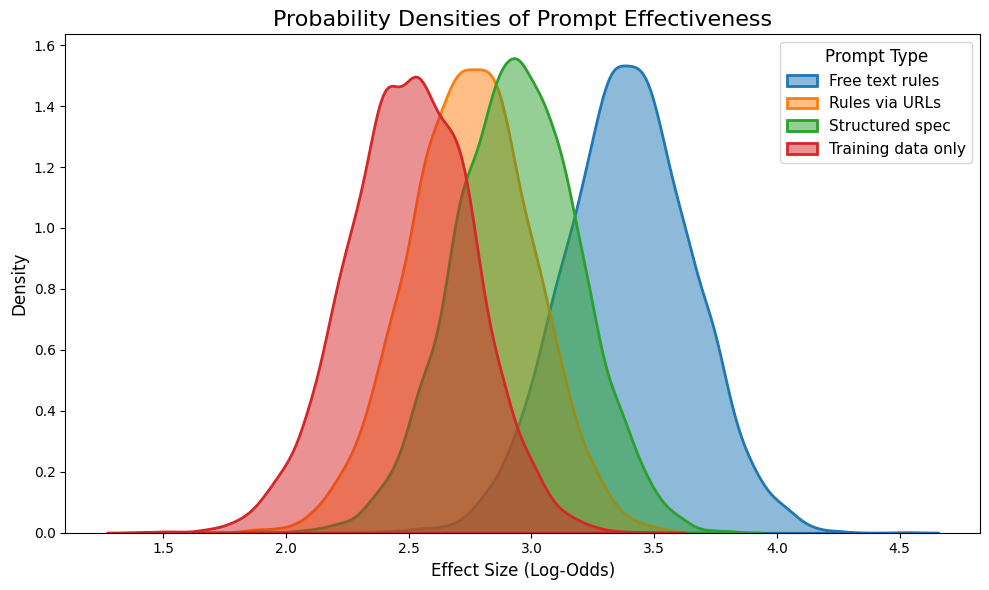

In [15]:

# Extract the multidimensional posterior object
posterior = idata.posterior["prompt_type"]
prompts = df['prompt_type'].unique()

fig, ax = plt.subplots(figsize=(10, 6))

# Loop through each prompt type and plot its distribution
for p in prompts:
    # Flatten the 4 chains and 2000 draws into a single 1D array of 8000 samples
    samples = posterior.sel(prompt_type_dim=p).values.flatten()
    
    # Plot the density curve with a nice shaded area
    sns.kdeplot(samples, label=p, fill=True, alpha=0.5, linewidth=2)

plt.title("Probability Densities of Prompt Effectiveness", fontsize=16)
plt.xlabel("Effect Size (Log-Odds)", fontsize=12)
plt.ylabel("Density", fontsize=12)

# Add a legend to clearly identify the curves
plt.legend(title="Prompt Type", fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

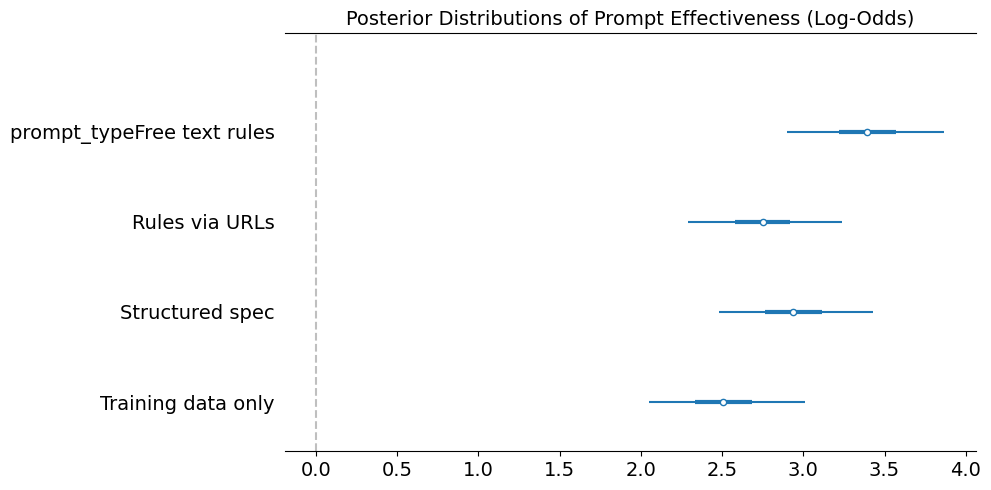

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

# Generate the base plot
az.plot_forest(
    idata, 
    var_names=["prompt_type"], 
    combined=True, 
    colors="C0", 
    ax=ax
)

# Grab the messy labels ArviZ generated
current_labels = [text.get_text() for text in ax.get_yticklabels()]

# Clean them up: Remove 'prompt_type\n', '[', and ']'
clean_labels = [
    label.replace('prompt_type\n', '').replace('[', '').replace(']', '') 
    for label in current_labels
]

# Apply the clean labels back to the axis
ax.set_yticklabels(clean_labels)

plt.title("Posterior Distributions of Prompt Effectiveness (Log-Odds)", fontsize=14)
plt.axvline(x=0, color='grey', linestyle='--', alpha=0.5) # A helpful reference line
plt.tight_layout()
plt.show()

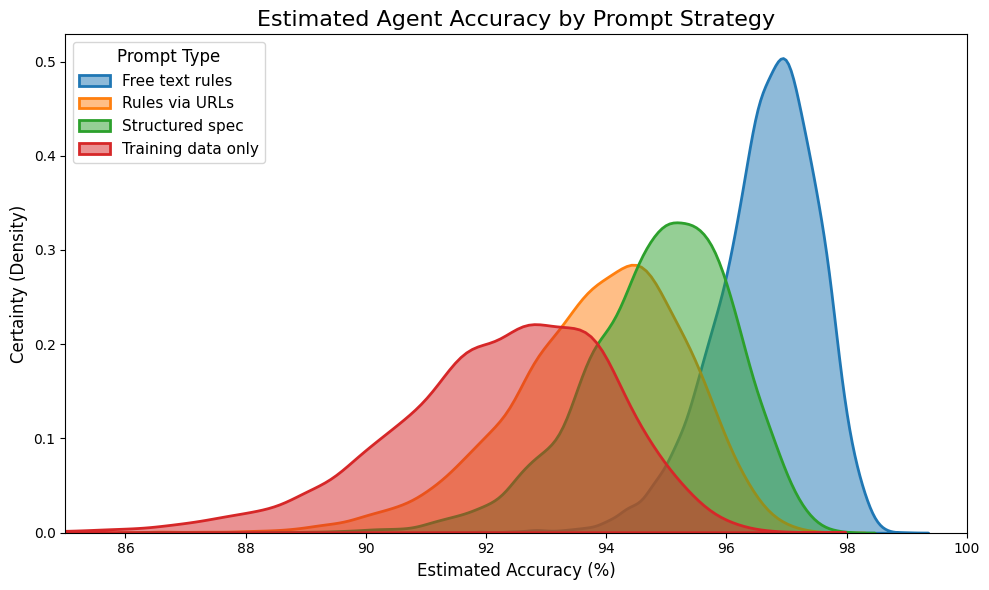

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import expit # This translates log-odds to probability

posterior = idata.posterior["prompt_type"]
prompts = df['prompt_type'].unique()

fig, ax = plt.subplots(figsize=(10, 6))

for p in prompts:
    # 1. Extract the raw log-odds samples
    samples_log_odds = posterior.sel(prompt_type_dim=p).values.flatten()
    
    # 2. Convert log-odds to Probability (0 to 1), then multiply by 100 for Percentage
    samples_percentage = expit(samples_log_odds) * 100
    
    # 3. Plot the new percentage-based distributions
    sns.kdeplot(samples_percentage, label=p, fill=True, alpha=0.5, linewidth=2)

plt.title("Estimated Agent Accuracy by Prompt Strategy", fontsize=16)
plt.xlabel("Estimated Accuracy (%)", fontsize=12) # Much better X-axis!
plt.ylabel("Certainty (Density)", fontsize=12)

plt.legend(title="Prompt Type", fontsize=11, title_fontsize=12, loc='upper left')

# Optional: Limit the x-axis to zoom in on the relevant high-accuracy range
plt.xlim(85, 100) 

plt.tight_layout()
plt.show()

In [17]:
import pandas as pd
import numpy as np
from scipy.special import expit

# Extract the posterior samples
posterior = idata.posterior["prompt_type"]
prompts = df['prompt_type'].unique()

# Define the baseline to compare against
baseline = "Training data only"
baseline_log_odds = posterior.sel(prompt_type_dim=baseline).values.flatten()

table_data = []

for p in prompts:
    # 1. Get log-odds and convert to accuracy percentages
    log_odds = posterior.sel(prompt_type_dim=p).values.flatten()
    accuracy_samples = expit(log_odds) * 100
    
    # 2. Calculate Median and 94% High-Density Interval (Credible Interval)
    median_acc = np.median(accuracy_samples)
    hdi_lower = np.percentile(accuracy_samples, 3)
    hdi_upper = np.percentile(accuracy_samples, 97)
    
    # 3. Calculate Odds Ratio vs Baseline
    odds_ratio = np.median(np.exp(log_odds - baseline_log_odds))
    
    # 4. Calculate Probability of being better than the baseline
    if p == baseline:
        prob_better = np.nan
    else:
        prob_better = np.mean(log_odds > baseline_log_odds) * 100
        
    # Append to our list
    table_data.append({
        "Prompt Strategy": p,
        "Est. Accuracy": f"{median_acc:.1f}%",
        "94% Credible Interval": f"[{hdi_lower:.1f}%, {hdi_upper:.1f}%]",
        "Odds Ratio (vs Baseline)": "-" if p == baseline else f"{odds_ratio:.2f}x",
        "Prob. > Baseline": "-" if p == baseline else f"{prob_better:.1f}%"
    })

# Convert to a DataFrame and sort by Accuracy
results_df = pd.DataFrame(table_data)
results_df = results_df.sort_values(by="Est. Accuracy", ascending=False).reset_index(drop=True)

# Display the clean table
print(results_df.to_string(index=False))

   Prompt Strategy Est. Accuracy 94% Credible Interval Odds Ratio (vs Baseline) Prob. > Baseline
   Free text rules         96.8%        [94.8%, 98.0%]                    2.44x           100.0%
   Structured spec         95.0%        [92.1%, 96.8%]                    1.55x            99.9%
    Rules via URLs         94.0%        [90.6%, 96.2%]                    1.28x            96.4%
Training data only         92.5%        [88.2%, 95.2%]                        -                -


In [18]:
results_df

,Prompt Strategy,Est. Accuracy,94% Credible Interval,Odds Ratio (vs Baseline),Prob. > Baseline
0,Free text rules,96.8%,"[94.8%, 98.0%]",2.44x,100.0%
1,Structured spec,95.0%,"[92.1%, 96.8%]",1.55x,99.9%
2,Rules via URLs,94.0%,"[90.6%, 96.2%]",1.28x,96.4%
3,Training data only,92.5%,"[88.2%, 95.2%]",-,-


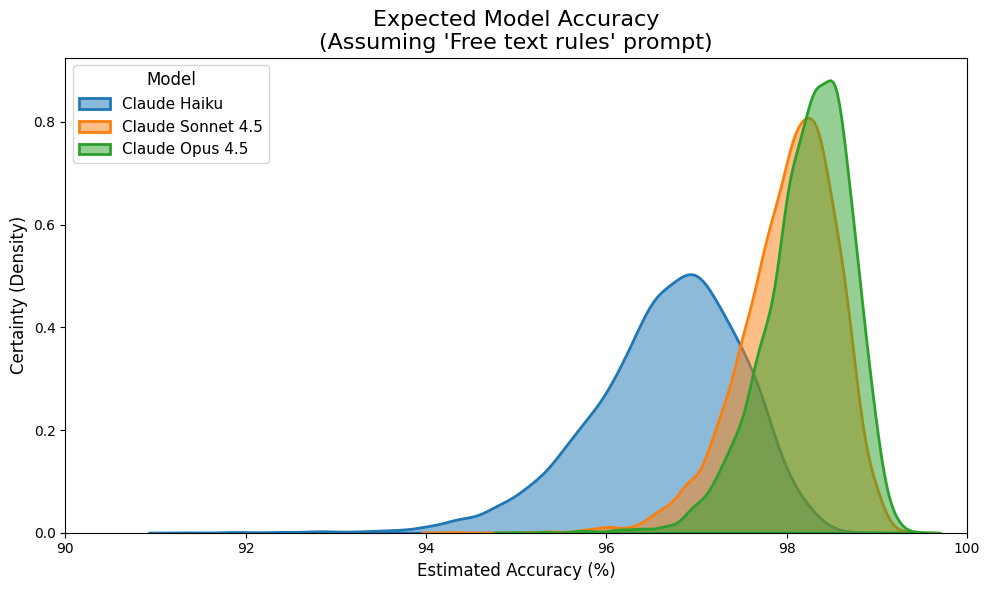

In [19]:

# 1. Extract the relative model effects from the posterior
sonnet_effect = idata.posterior["model_name"].sel(model_name_dim="claude-sonnet-4-5").values.flatten()
opus_effect = idata.posterior["model_name"].sel(model_name_dim="claude-opus-4-5").values.flatten()

# Haiku was the reference category in the regression, so its effect is 0
haiku_effect = np.zeros_like(sonnet_effect) 

# 2. Extract our anchor (The log-odds of the winning 'Free text rules' prompt)
anchor_log_odds = idata.posterior["prompt_type"].sel(prompt_type_dim="Free text rules").values.flatten()

# 3. Combine them to get absolute log-odds for each model
models_log_odds = {
    "Claude Haiku": anchor_log_odds + haiku_effect,
    "Claude Sonnet 4.5": anchor_log_odds + sonnet_effect,
    "Claude Opus 4.5": anchor_log_odds + opus_effect
}

# 4. Plotting
fig, ax = plt.subplots(figsize=(10, 6))

for model_name, log_odds in models_log_odds.items():
    # Convert log-odds to Percentage Accuracy
    accuracy_percentage = expit(log_odds) * 100
    sns.kdeplot(accuracy_percentage, label=model_name, fill=True, alpha=0.5, linewidth=2)

plt.title("Expected Model Accuracy\n(Assuming 'Free text rules' prompt)", fontsize=16)
plt.xlabel("Estimated Accuracy (%)", fontsize=12)
plt.ylabel("Certainty (Density)", fontsize=12)
plt.legend(title="Model", fontsize=11, title_fontsize=12, loc='upper left')

# Zoom in on the high accuracy range
plt.xlim(90, 100) 
plt.tight_layout()
plt.show()

In [20]:
import pandas as pd

table_data = []
baseline_name = "Claude Haiku"
baseline_log_odds = models_log_odds[baseline_name]

for model_name, log_odds in models_log_odds.items():
    # Convert to accuracy percentages
    accuracy_samples = expit(log_odds) * 100
    
    # Calculate Median and 94% HDI
    median_acc = np.median(accuracy_samples)
    hdi_lower = np.percentile(accuracy_samples, 3)
    hdi_upper = np.percentile(accuracy_samples, 97)
    
    # Calculate Odds Ratio vs Haiku
    # (We calculate this using the raw effect sizes to isolate the model's power)
    odds_ratio = np.median(np.exp(log_odds - baseline_log_odds))
    
    # Calculate Probability of being better than Haiku
    if model_name == baseline_name:
        prob_better = np.nan
    else:
        prob_better = np.mean(log_odds > baseline_log_odds) * 100
        
    table_data.append({
        "Model": model_name,
        "Est. Accuracy (w/ Free Text)": f"{median_acc:.1f}%",
        "94% Credible Interval": f"[{hdi_lower:.1f}%, {hdi_upper:.1f}%]",
        "Odds Ratio (vs Haiku)": "-" if model_name == baseline_name else f"{odds_ratio:.2f}x",
        "Prob. > Haiku": "-" if model_name == baseline_name else f"{prob_better:.1f}%"
    })

# Convert to a DataFrame and sort by Accuracy
model_results_df = pd.DataFrame(table_data)
model_results_df = model_results_df.sort_values(by="Est. Accuracy (w/ Free Text)", ascending=False).reset_index(drop=True)

print(model_results_df.to_string(index=False))

            Model Est. Accuracy (w/ Free Text) 94% Credible Interval Odds Ratio (vs Haiku) Prob. > Haiku
  Claude Opus 4.5                        98.3%        [97.2%, 99.0%]                 1.92x        100.0%
Claude Sonnet 4.5                        98.1%        [96.9%, 98.8%]                 1.72x        100.0%
     Claude Haiku                        96.8%        [94.8%, 98.0%]                     -             -


In [21]:


# 1. Standardize the column names for the Prompt results
results_df = results_df.rename(columns={
    "Prompt Strategy": "Level",
    "Prob. > Baseline": "P(> Baseline)"
})
results_df.insert(0, "Variable", "Prompt Strategy")

# 2. Standardize the column names for the Model results
model_results_df = model_results_df.rename(columns={
    "Model": "Level", 
    "Est. Accuracy (w/ Free Text)": "Est. Accuracy",
    "Odds Ratio (vs Haiku)": "Odds Ratio (vs Baseline)",
    "Prob. > Haiku": "P(> Baseline)"
})
model_results_df.insert(0, "Variable", "Base Model")

# 3. Concatenate them together
final_table = pd.concat([results_df, model_results_df], ignore_index=True)

# 4. Create a MultiIndex to give it that "Regression Output" nested look
final_table = final_table.set_index(["Variable", "Level"])

# Print the final result
print(final_table.to_string())

                                   Est. Accuracy 94% Credible Interval Odds Ratio (vs Baseline) P(> Baseline)
Variable        Level                                                                                        
Prompt Strategy Free text rules            96.8%        [94.8%, 98.0%]                    2.44x        100.0%
                Structured spec            95.0%        [92.1%, 96.8%]                    1.55x         99.9%
                Rules via URLs             94.0%        [90.6%, 96.2%]                    1.28x         96.4%
                Training data only         92.5%        [88.2%, 95.2%]                        -             -
Base Model      Claude Opus 4.5            98.3%        [97.2%, 99.0%]                    1.92x        100.0%
                Claude Sonnet 4.5          98.1%        [96.9%, 98.8%]                    1.72x        100.0%
                Claude Haiku               96.8%        [94.8%, 98.0%]                        -             -


In [24]:
final_table

Est. Accuracy 94% Credible Interval  \
Variable        Level                                                    
Prompt Strategy Free text rules            96.8%        [94.8%, 98.0%]   
                Structured spec            95.0%        [92.1%, 96.8%]   
                Rules via URLs             94.0%        [90.6%, 96.2%]   
                Training data only         92.5%        [88.2%, 95.2%]   
Base Model      Claude Opus 4.5            98.3%        [97.2%, 99.0%]   
                Claude Sonnet 4.5          98.1%        [96.9%, 98.8%]   
                Claude Haiku               96.8%        [94.8%, 98.0%]   

                                   Odds Ratio (vs Baseline) P(> Baseline)  
Variable        Level                                                      
Prompt Strategy Free text rules                       2.44x        100.0%  
                Structured spec                       1.55x         99.9%  
                Rules via URLs                        1.28x         96.4%  
                Training data only                        -             -  
Base Model      Claude Opus 4.5                       1.92x        100.0%  
                Claude Sonnet 4.5                     1.72x        100.0%  
                Claude Haiku                              -             -